In [1]:
%pip install scikit-learn pandas matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:


,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Missing values:
Sepal Length    0
Sepal Width     0
Petal Length    0
Petal Width     0
Species         0
dtype: int64

Class distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64


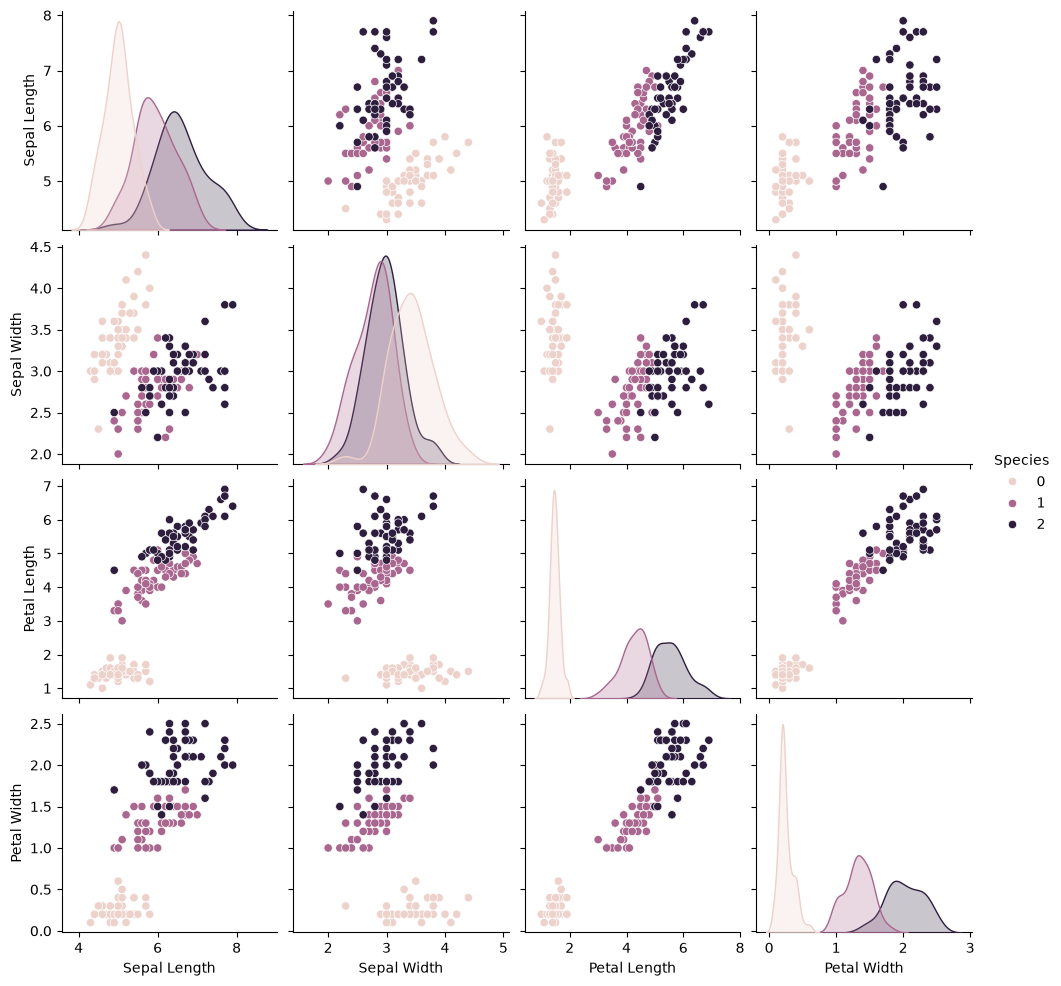

Training samples: 120
Testing samples: 30

Training model...
Training completed!

MODEL RESULTS
Accuracy: 96.66666666666667 %

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



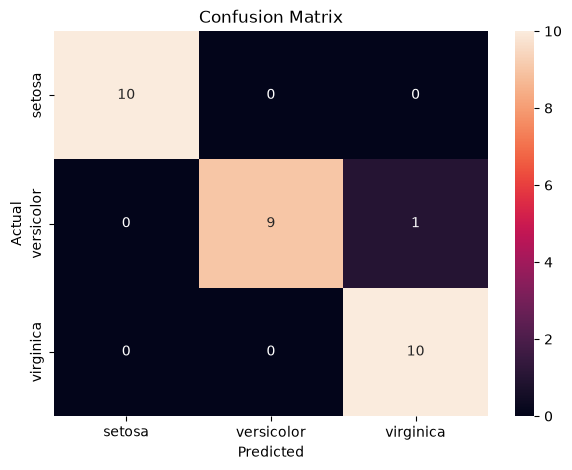


NEW FLOWER PREDICTION
Predicted Species: setosa

Multiple Predictions:
Flower 1: setosa
Flower 2: versicolor
Flower 3: virginica

Model saved successfully!
iris_ann_model.pkl
iris_scaler.pkl


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Classes:", iris.target_names)


df = pd.DataFrame(
    X,
    columns=[
        "Sepal Length",
        "Sepal Width",
        "Petal Length",
        "Petal Width"
    ]
)

df["Species"] = y

print("\nFirst 5 rows:")
display(df.head())


print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Species"].value_counts())


sns.pairplot(
    df,
    hue="Species"
)

plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

print("\nTraining model...")

model.fit(
    X_train,
    y_train
)

print("Training completed!")

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================================")
print("MODEL RESULTS")
print("================================")

print("Accuracy:", accuracy * 100, "%")


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()



new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower_scaled = scaler.transform(
    new_flower
)

prediction = model.predict(
    new_flower_scaled
)

print("\n================================")
print("NEW FLOWER PREDICTION")
print("================================")

print(
    "Predicted Species:",
    iris.target_names[prediction[0]]
)


new_flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.7, 3.0, 5.2, 2.3]
])

new_flowers_scaled = scaler.transform(
    new_flowers
)

predictions = model.predict(
    new_flowers_scaled
)

print("\nMultiple Predictions:")

for i, prediction in enumerate(predictions):

    print(
        f"Flower {i + 1}:",
        iris.target_names[prediction]
    )


import joblib

joblib.dump(
    model,
    "iris_ann_model.pkl"
)

joblib.dump(
    scaler,
    "iris_scaler.pkl"
)

print("\nModel saved successfully!")
print("iris_ann_model.pkl")
print("iris_scaler.pkl")